This notebook provides a structured environment for evaluating the **Frozen** multimodal few-shot learner.
It is designed to:
1.  **Load the model once** to save time.
2.  **Visualize inputs and outputs** clearly.
3.  **Isolate test cases** (Zero-Shot, Few-Shot, Knowledge, Concept Binding) into individual cells for easy iteration.


In [280]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = '6'
import textwrap
import random
from dataclasses import dataclass
from typing import List, Union
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import timm
from transformers import GPT2Tokenizer, GPT2LMHeadModel, GPTNeoForCausalLM

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")


In [2]:

# --- Configuration & Device Setup ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Running on {DEVICE}")

def set_seed(seed_value=42):
    # Set seed for reproducibility
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(42)


🚀 Running on cuda


In [3]:

# --- Model Classes ---

@dataclass
class FrozenConfig:
    vision_encoder_name: str = "resnet50"
    language_model_name: str = "gpt2-large"
    visual_prefix_length: int = 2
    vision_hidden_dim: int = 2048
    lm_hidden_dim: int = 1280

class VisionEncoder(nn.Module):
    def __init__(self, config: FrozenConfig):
        super().__init__()
        self.config = config
        # Create backbone (ResNet50 by default)
        self.backbone = timm.create_model(
            config.vision_encoder_name, pretrained=True, num_classes=0, global_pool=''
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        # Projects vision features to the dimension of the LM embeddings
        self.projection = nn.Linear(config.vision_hidden_dim, config.visual_prefix_length * config.lm_hidden_dim)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.backbone(images)
        features = self.pool(features).flatten(1)
        prefix = self.projection(features)
        # Reshape to [Batch, Prefix_Length, LM_Dim]
        return prefix.view(-1, self.config.visual_prefix_length, self.config.lm_hidden_dim)

class FrozenModel(nn.Module):
    def __init__(self, config: FrozenConfig):
        super().__init__()
        self.config = config
        self.vision_encoder = VisionEncoder(config)
        
        # Load the Language Model
        if "gpt-neo" in config.language_model_name.lower():
            self.language_model = GPTNeoForCausalLM.from_pretrained(config.language_model_name)
        else:
            self.language_model = GPT2LMHeadModel.from_pretrained(config.language_model_name)

    def get_input_embeddings(self):
        return self.language_model.get_input_embeddings()


In [4]:

# --- Generation Logic ---

def generate_from_interleaved(
    model: FrozenModel,
    tokenizer: GPT2Tokenizer,
    prompt_items: List[Union[str, Image.Image]],
    max_new_tokens: int = 20,
    temperature: float = 0.0, 
    device: str = DEVICE
) -> str:
    # Generates text from a sequence of images and text.
    # Stops generation when a newline or new 'Question:' marker is found.
    
    # Standard ImageNet Normalization
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    embeddings_list = []
    
    with torch.no_grad():
        # 1. Build the interleaved embedding sequence
        for item in prompt_items:
            if isinstance(item, Image.Image):
                # Process Image -> Visual Prefix
                img_tensor = transform(item).unsqueeze(0).to(device)
                visual_prefix = model.vision_encoder(img_tensor)
                embeddings_list.append(visual_prefix)
            elif isinstance(item, str):
                # Process Text -> Token Embeddings
                tokens = tokenizer(item, return_tensors="pt", add_special_tokens=False).input_ids.to(device)
                text_embeds = model.get_input_embeddings()(tokens)
                embeddings_list.append(text_embeds)

        inputs_embeds = torch.cat(embeddings_list, dim=1)
        generated_tokens = []

        # 2. Autoregressive Generation Loop
        for _ in range(max_new_tokens):
            outputs = model.language_model(inputs_embeds=inputs_embeds)
            next_token_logits = outputs.logits[:, -1, :]
            
            if temperature == 0:
                next_token_id = torch.argmax(next_token_logits, dim=-1).unsqueeze(0)
            else:
                next_token_logits = next_token_logits / temperature
                probs = F.softmax(next_token_logits, dim=-1)
                next_token_id = torch.multinomial(probs, num_samples=1)

            # Stop if EOS token is generated
            if next_token_id.item() == tokenizer.eos_token_id:
                break
                
            generated_tokens.append(next_token_id.item())
            next_token_embed = model.get_input_embeddings()(next_token_id)
            inputs_embeds = torch.cat([inputs_embeds, next_token_embed], dim=1)

    # 3. Decode and Cleanup
    decoded_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    
    # Heuristic stopping: Stop at newlines or next Question/Answer tags
    stop_words = ["Question:", "Answer:", "\n"]
    for word in stop_words:
        if word in decoded_text:
            decoded_text = decoded_text.split(word)[0]
        
    return decoded_text.strip()



## 1. Load Model Checkpoint
Run this cell **once**. You do not need to run it again unless you change the checkpoint file.
Make sure your `CHECKPOINT_FILE` path is correct.


In [318]:

def load_frozen_model(checkpoint_path):
    config = FrozenConfig()
    print(f"Initializing model structure ({config.language_model_name})...")
    tokenizer = GPT2Tokenizer.from_pretrained(config.language_model_name)
    model = FrozenModel(config)

    if os.path.exists(checkpoint_path):
        print(f"Loading weights from {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        
        # Handle different saving formats
        if 'vision_encoder_state_dict' in checkpoint:
            model.vision_encoder.load_state_dict(checkpoint['vision_encoder_state_dict'])
        else:
            model.load_state_dict(checkpoint, strict=False)
            
        model.to(DEVICE)
        model.eval()
        print("✅ Model loaded successfully!")
        return model, tokenizer
    else:
        raise FileNotFoundError(f"Checkpoint not found at {checkpoint_path}")

# --- USER CONFIGURATION ---
CHECKPOINT_FILE = "frozen_checkpoints/frozen_checkpoint_epoch1.pt" 

# Load the model
try:
    model, tokenizer = load_frozen_model(CHECKPOINT_FILE)
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("Please verify the CHECKPOINT_FILE path.")


Initializing model structure (gpt2-large)...
Loading weights from frozen_checkpoints/frozen_checkpoint_epoch1.pt...
✅ Model loaded successfully!



## 2. Setup Images and Helper Functions
Define your image paths here. The helper function `show_results` will visualize the input prompts alongside the model's output.


In [333]:

# Define paths to your test images
MY_IMAGES = {
    "vase_1": "images/vase_1.jpg",
    "vase_on_table": "images/vase_on_table.jpg",
    "car_old": "images/car_old.jpg",
    "table_1": "images/table_1.jpg",
    "dog_1": "images/dog_1.jpg",
    "dog_2": "images/dog_2.jpg",
    "dog_3": "images/dog_3.jpg",
    "dog_4": "images/dog_4.jpg",
    "dog_5": "images/dog_5.jpg",
    "car_1": "images/car_1.jpg",
    "car_2": "images/car_2.jpg",
    "car_3": "images/car_3.jpg",
    "car_4": "images/car_4.jpg",
    "car_5": "images/car_5.jpg",
    "plane_1": "images/plane_1.jpg",
    "plane_2": "images/plane_2.jpg",
    "plane_3": "images/plane_3.jpg",
    "plane_3": "images/plane_3.jpg",
    "plane_4": "images/plane_4.jpg",
    "plane_5": "images/plane_5.jpg",
    "lion_1": "images/lion_1.jpg",
    "lion_2": "images/lion_2.jpg",
    "lion_3": "images/lion_3.jpg",
    "lion_4": "images/lion_4.jpg",
    "lion_5": "images/lion_5.jpg", 
    "cat_1": "images/cat_1.jpg",
    "cat_2": "images/cat_2.jpg",
    "cat_3": "images/cat_3.jpg",
    "cat_4": "images/cat_4.jpg",
    "cat_5": "images/cat_5.jpg",
    "phone_1": "images/phone_1.jpg",
    "phone_2": "images/phone_2.jpg",
    "phone_3": "images/phone_3.jpg",
    "phone_4": "images/phone_4.jpg",
    "phone_5": "images/phone_5.jpg",
    "microscope_1": "images/microscope_2.jpg",
    "computer": "images/computer.jpg",
    "telephone": "images/telephone.jpg",
    "lightbulb": "images/lightbulb.jpg",

    # Add more images here as needed
}

def load_img(key):
    path = MY_IMAGES.get(key)
    if not path or not os.path.exists(path):
        print(f"⚠️ Missing image for key '{key}' at {path}")
        return None
    return Image.open(path).convert("RGB")

import matplotlib.pyplot as plt
from PIL import Image
import textwrap
import math

import matplotlib.pyplot as plt
from PIL import Image
import textwrap
import math

def show_results( prompt_items, prediction, title="Test Result", cols=3):
    display_items = prompt_items + [prediction]
    num_items = len(display_items)

    rows = math.ceil(num_items / cols)
    
    # 1. Reduced Figure Size for smaller images and less whitespace
    # Width=12, Height=3 per row (down from 5)
    plt.figure(figsize=(12, 3 * rows))
    
    # 2. Title Centering Fix
    # x=0.5 locks it to the horizontal center of the figure
    # ha='center' ensures the text aligns perfectly to that point
    # y=0.98 keeps it at the top but tight to the content
    plt.suptitle(title, fontsize=12, weight='bold', x=0.5, y=0.98, ha='center')
    
    for i, item in enumerate(display_items):
        # --- Grid Position ---
        row = i // cols
        if row % 2 == 0:
            col = i % cols
            direction = "right"
        else:
            col = (cols - 1) - (i % cols)
            direction = "left"
            
        subplot_idx = (row * cols) + col + 1
        ax = plt.subplot(rows, cols, subplot_idx)
        
        # --- Content Rendering ---
        is_output = (i == num_items - 1)
        
        if isinstance(item, Image.Image):
            # Resize helps visually, but figsize controls the actual plot size
            item = item.resize((100, 100))
            ax.imshow(item)
            ax.set_title(f"Step {i+1} (Image)", fontsize=10)
            ax.axis('off')
        else:
            display_text = str(item).replace("\n", " ").strip()
            wrapped_text = "\n".join(textwrap.wrap(display_text, width=25))
            
            ax.text(0.5, 0.5, wrapped_text, ha='center', va='center', 
                    fontsize=10, color='black')
            
            if is_output:
                ax.set_title("Output", fontsize=10, weight='bold')
            else:
                ax.set_title(f"Step {i+1} (Text)", fontsize=10, color='gray')
            ax.axis('off')

        # --- Arrow Logic ---
        if i < num_items - 1:
            is_row_end = (i % cols) == (cols - 1)
            arrow_props = dict(facecolor='black', shrink=0.05, width=1, headwidth=5)
            
            if is_row_end:
                ax.annotate('', xy=(0.5, -0.1), xytext=(0.5, 0.05),
                            xycoords='axes fraction', arrowprops=arrow_props)
            elif direction == "right":
                ax.annotate('', xy=(1.1, 0.5), xytext=(0.95, 0.5),
                            xycoords='axes fraction', arrowprops=arrow_props)
            elif direction == "left":
                ax.annotate('', xy=(-0.1, 0.5), xytext=(0.05, 0.5),
                            xycoords='axes fraction', arrowprops=arrow_props)

    # 3. Layout Cleanup
    # rect=[0, 0, 1, 0.95] reserves the top 5% for the title, 
    # preventing the plots from pushing the title off-center or off-screen.
    plt.tight_layout(pad=1.0, rect=[0, 0, 1, 0.95])
    plt.show()


## 3. Test Case: Zero-Shot VQA
**Capability:** Evaluation of the model's ability to identify objects without any prior examples in the prompt.
**Prompt:** `[Image] Question: What is this object called? Answer:`


Running Zero-Shot VQA Tests...


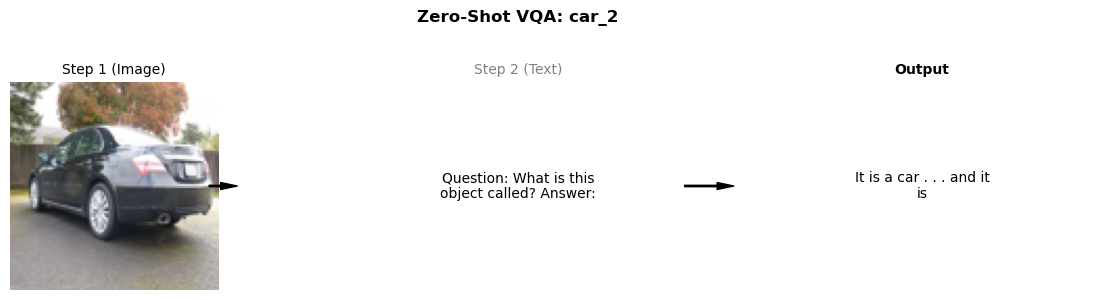

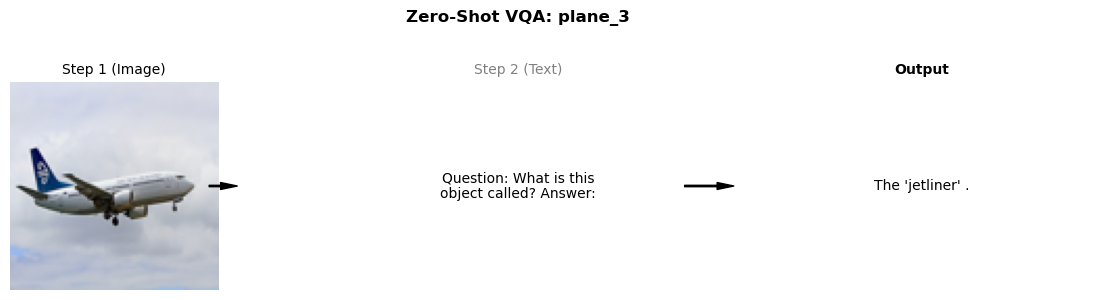

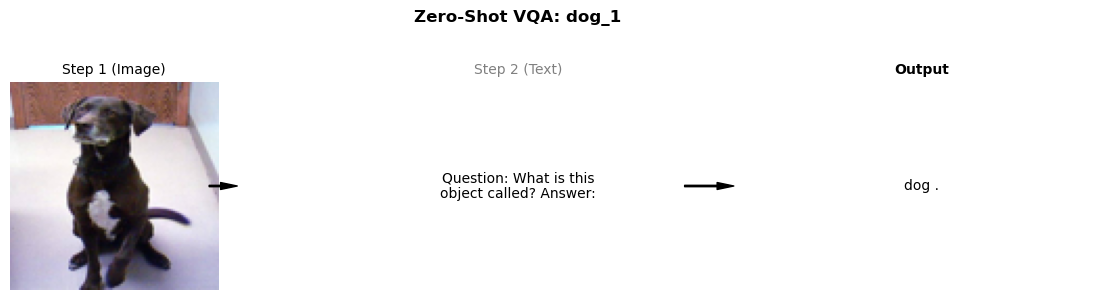

In [335]:

target_keys = ["car_2", "plane_3", "dog_1"] 

print("Running Zero-Shot VQA Tests...")

for key in target_keys:
    img = load_img(key)
    if img:
        # Construct Prompt
        prompt = [
            img, 
            "Question: What is this object called?\nAnswer:" 
        ]
        
        # Generate
        output = generate_from_interleaved(model, tokenizer, prompt, max_new_tokens=10)
        
        # Visualize
        show_results(prompt, prediction=output, title=f"Zero-Shot VQA: {key}")
    else:
        print(f"Skipping {key} (Image not loaded)")



## 4. Test Case: Rapid Task Adaptation (Few-Shot VQA)
**Capability:** Evaluation of whether providing examples (shots) improves the model's response.
**Prompt Structure:** `[Img1] Q:.. A: Dog. [Img2] Q:.. A: Plane. [TargetImg] Q:.. A:`


Running Few-Shot VQA Test...
Table .


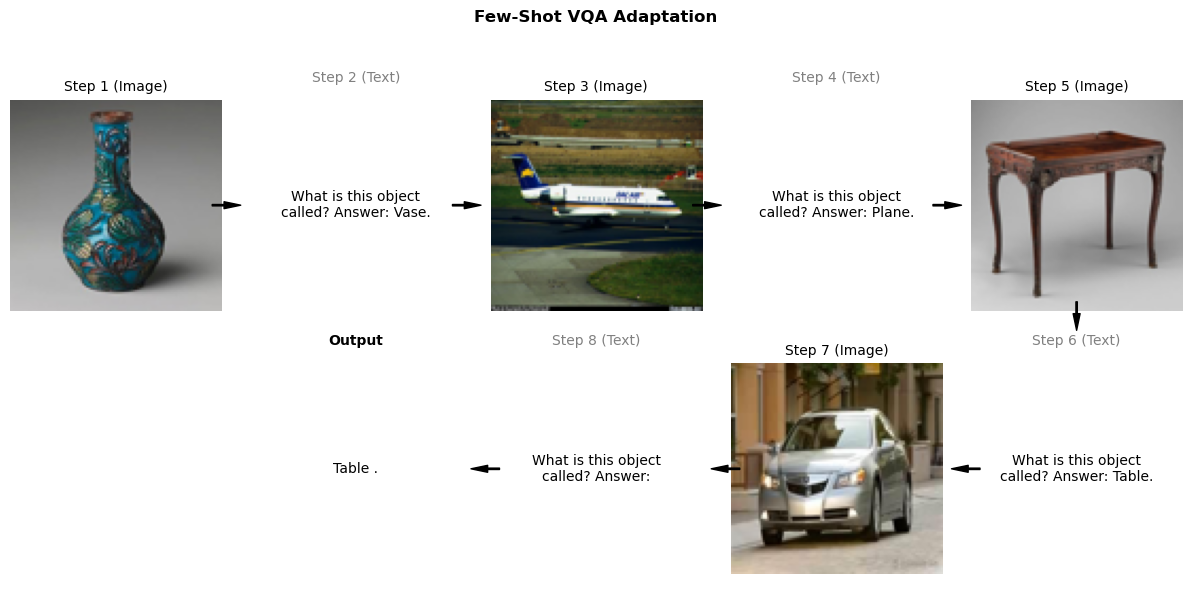

In [369]:

print("Running Few-Shot VQA Test...")

# Define Support Set and Target
img_supp2 = load_img("vase_1")
img_supp1 = load_img("table_1")
img_supp4 = load_img("car_2") 
img_supp3 = load_img("plane_2")
img_supp5 = load_img("phone_2")
img_target = load_img("car_4")

if img_supp1 and img_supp2 and img_target:
    # Construct Few-Shot Prompt
    prompt = [
        
        # img_supp4, "The object here is a Car.\n",
        img_supp2, "What is this object called?\nAnswer: Vase.\n",
        img_supp3, "What is this object called?\nAnswer: Plane.\n",
        img_supp1, "What is this object called?\nAnswer: Table.\n",
        # img_supp5, "The object here is a Phone.\n ",
        img_target, "What is this object called?\nAnswer:" 
    ]
    
    # Generate
    output = generate_from_interleaved(model, tokenizer, prompt, max_new_tokens=20)
    
    # Visualize
    print(output)
    show_results(prompt, prediction=output, title="Few-Shot VQA Adaptation", cols=5)
else:
    print("⚠️ Missing images for Few-Shot test. Check your MY_IMAGES paths.")



## 5. Test Case: Encyclopedic Knowledge
**Capability:** Testing if the model can retrieve external knowledge about the visual concept (e.g., identifying an inventor).
**Prompt:** `[Image] Question: Who invented this object? Answer:`


Running Encyclopedic Knowledge Test...


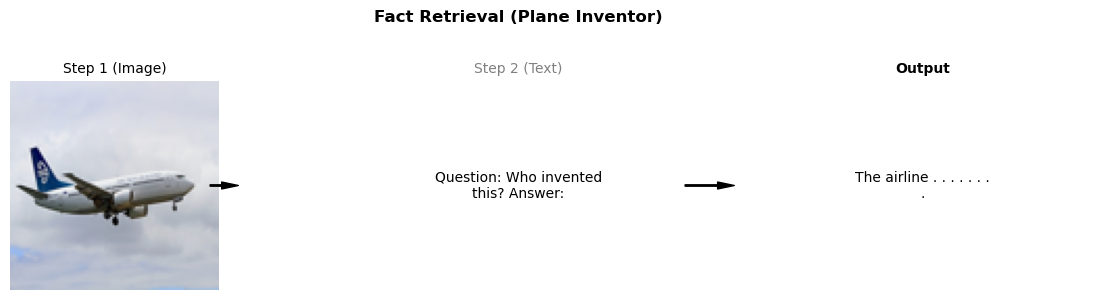

In [371]:

print("Running Encyclopedic Knowledge Test...")

img_fact = load_img("plane_3")

if img_fact:
    prompt = [
        img_fact, 
        "Question: Who invented this? Answer:"
    ]
    
    output = generate_from_interleaved(model, tokenizer, prompt, max_new_tokens=10)
    
    show_results(prompt, prediction=output, title="Fact Retrieval (Plane Inventor)")
else:
    print("⚠️ Missing image for Fact Retrieval test.")


Running Encyclopedic Knowledge Test...


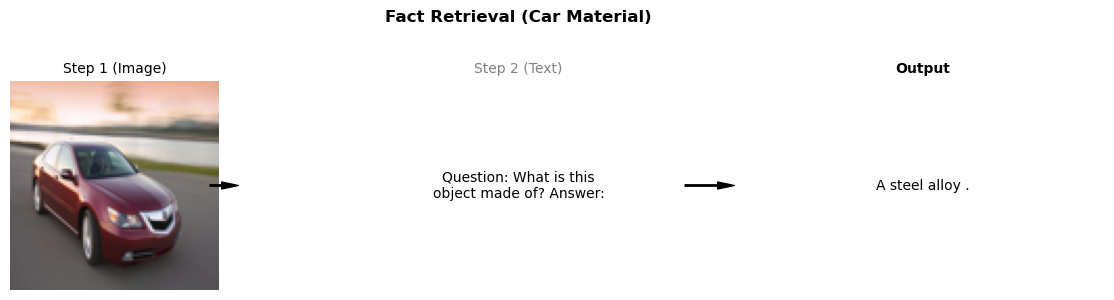

In [339]:

print("Running Encyclopedic Knowledge Test...")

img_fact = load_img("car_3")

if img_fact:
    prompt = [
        img_fact, 
        "Question: What is this object made of?\nAnswer:"
    ]
    
    output = generate_from_interleaved(model, tokenizer, prompt, max_new_tokens=10)
    
    show_results(prompt, prediction=output, title="Fact Retrieval (Car Material)")
else:
    print("⚠️ Missing image for Fact Retrieval test.")


Running 'Inventor' Test with Task Induction & QA Format...


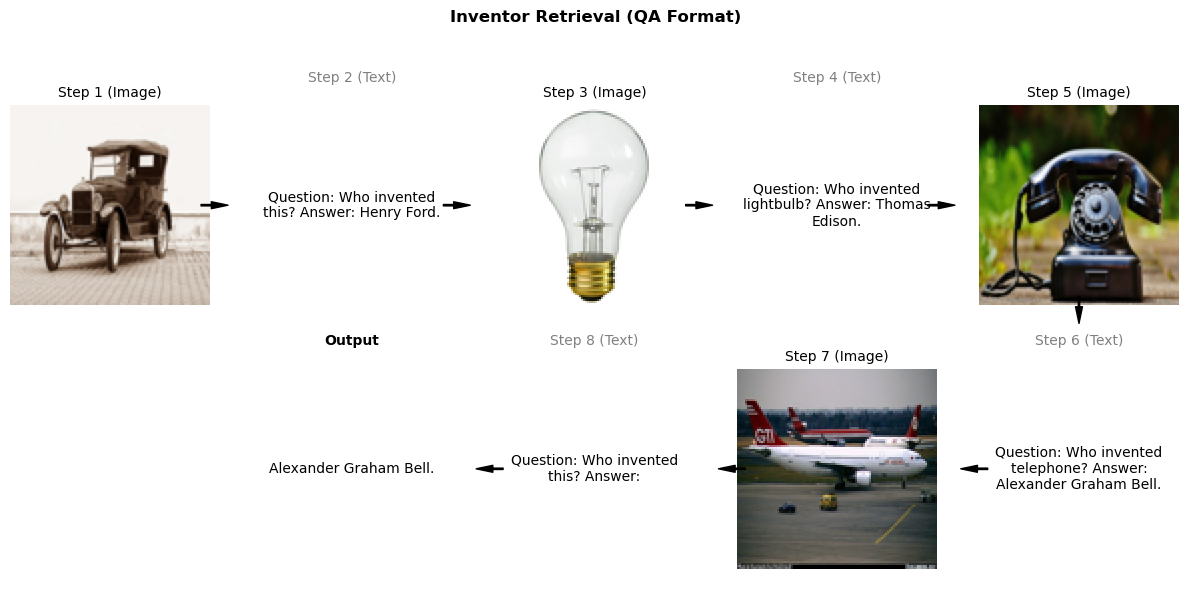

Alexander Graham Bell.


: 

In [374]:
print("Running 'Inventor' Test with Task Induction & QA Format...")

# Load Images
img_microscope = load_img("microscope_1")
img_lightbulb = load_img("lightbulb")
img_telephone = load_img("telephone")
img_car = load_img("car_old")
img_plane = load_img("plane_4")

if all([img_microscope, img_lightbulb, img_telephone, img_car, img_plane]):
    prompt = [
        # --- TASK INDUCTION (Instruction) ---
        # The paper suggests adding explanatory text to define the task 
            
        # Shot 1
        img_car, " Question: Who invented this?\nAnswer: Henry Ford.\n",
        
        # Shot 2
         img_lightbulb, " Question: Who invented lightbulb?\nAnswer: Thomas Edison.\n",
        
        # Shot 3
        img_telephone," Question: Who invented telephone?\nAnswer: Alexander Graham Bell.\n", 
        
        # # Shot 4 (The one missing in your previous code)
        # " Question: Who invented microscope?\nAnswer: Zacharias Janssen.\n", img_microscope, 
        
        # Target
        img_plane, " Question: Who invented this?\nAnswer:",
    ]
    
    # Note: The paper notes this task often requires "cherry-picking from around 5 seeds"
    # If this fails, try running it inside a loop with different seeds/temperatures.
    output = generate_from_interleaved(model, tokenizer, prompt, max_new_tokens=20)
    
    show_results(prompt, prediction=output, title="Inventor Retrieval (QA Format)", cols=5)
    print(output)
else:
    print("⚠️ Missing images. Check your MY_IMAGES dictionary.")


## 6. Test Case: Fast Concept Binding (Nonsense Words)
**Capability:** Testing if the model can learn *new* associations in-context.
**Task:** We show it a cat and call it a "dax". We show it a dog and call it a "blicket". Then we show a new cat and see if it calls it a "dax".


Running Fast Concept Binding Test...
Raw Output: dax.


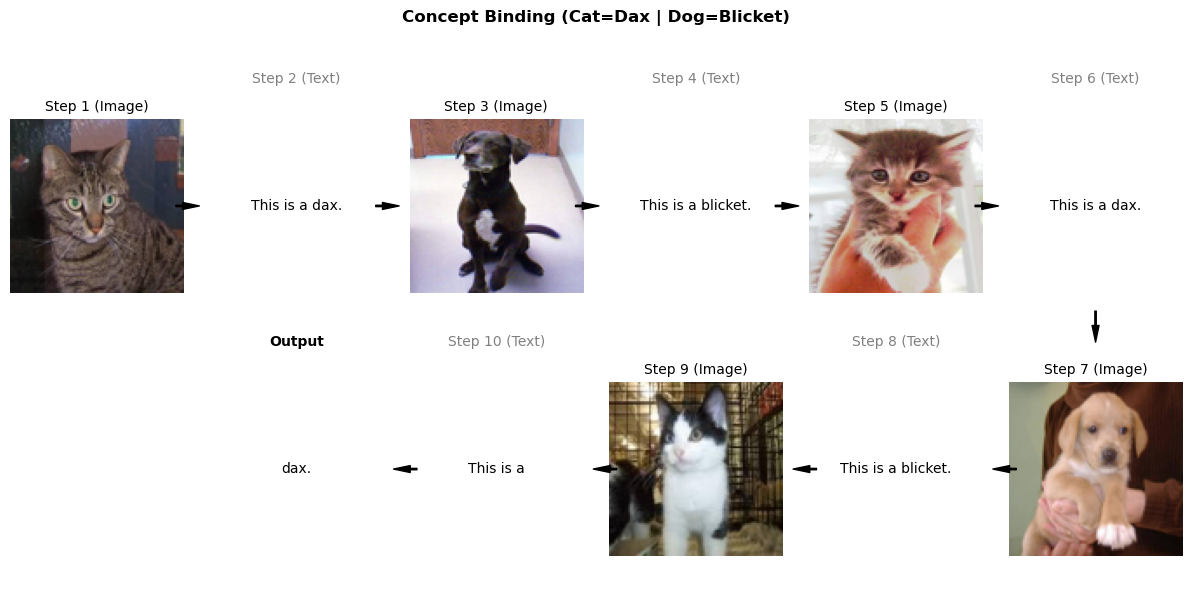

In [344]:

print("Running Fast Concept Binding Test...")

# Using cats and dogs as proxies for "dax" and "blicket"
img_teach_1 = load_img("cat_1")   # "This is a dax"
img_teach_2 = load_img("dog_1")   # "This is a blicket"
img_query = load_img("cat_3")     # Should be "dax"
img_teach_3 = load_img("cat_2")   # "This is a dax"
img_teach_4 = load_img("dog_2")   # "This is a blicket"
if img_teach_1 and img_teach_2 and img_query:
    prompt = [
        # Support Shots (Note the leading space for GPT-2 tokenization)
        img_teach_1, " This is a dax.\n", 
        img_teach_2, " This is a blicket.\n", 
          # Support Shots (Note the leading space for GPT-2 tokenization)
        img_teach_3, " This is a dax.\n", 
        img_teach_4, " This is a blicket.\n",       
        # Query
        img_query, " This is a" 
    ]
    
    output = generate_from_interleaved(model, tokenizer, prompt, max_new_tokens=5)
    
    print(f"Raw Output: {output}")
    show_results(prompt, prediction=output.strip(), title="Concept Binding (Cat=Dax | Dog=Blicket)", cols = 6)
else:
    print("⚠️ Missing images for Concept Binding test.")


Running Fast Concept Binding Test...
Raw Output: cat .


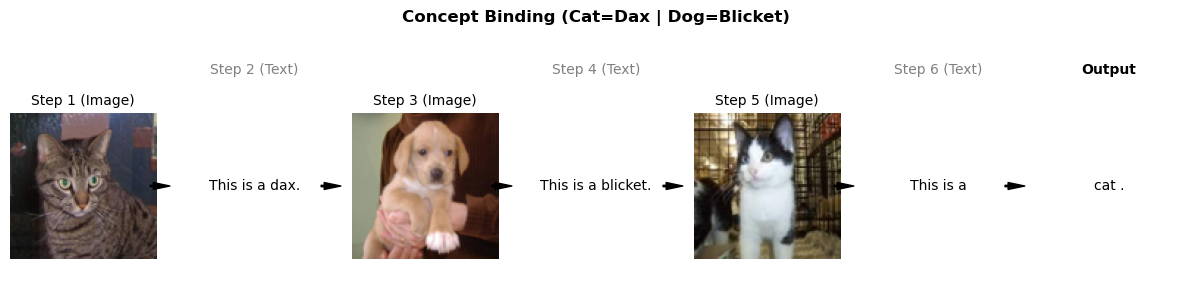

In [345]:

print("Running Fast Concept Binding Test...")

# Using cats and dogs as proxies for "dax" and "blicket"
img_teach_1 = load_img("cat_1")   # "This is a dax"
img_teach_2 = load_img("dog_1")   # "This is a blicket"
img_query = load_img("cat_3")     # Should be "dax"
img_teach_3 = load_img("cat_2")   # "This is a dax"
img_teach_4 = load_img("dog_2")   # "This is a blicket"
if img_teach_1 and img_teach_2 and img_query:
    prompt = [
        # Support Shots (Note the leading space for GPT-2 tokenization)
        img_teach_1, " This is a dax.\n", 
        # img_teach_2, " This is a blicket.\n", 
          # Support Shots (Note the leading space for GPT-2 tokenization)
        # img_teach_3, " This is a dax.\n", 
        img_teach_4, " This is a blicket.\n",       
        # Query
        img_query, " This is a" 
    ]
    
    output = generate_from_interleaved(model, tokenizer, prompt, max_new_tokens=5)
    
    print(f"Raw Output: {output}")
    show_results(prompt, prediction=output.strip(), title="Concept Binding (Cat=Dax | Dog=Blicket)", cols =7)
else:
    print("⚠️ Missing images for Concept Binding test.")


####
Fast-VQA (Multimodal)
####
This tests deep understanding. You define two objects with nonsense names ("blicket", "dax") and then ask a question about a third image that contains both, requiring the model to map the names and reason about their relationship (e.g., material properties).

Fast-VQA task...
Raw Output: . . . . this is a dax made of a white oak .


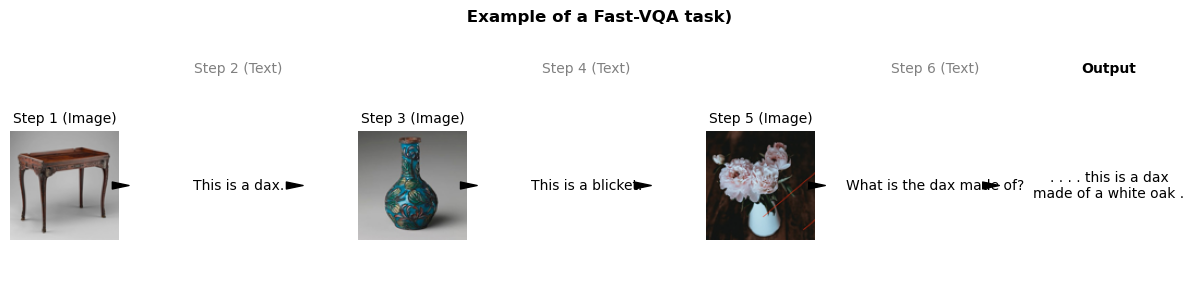

In [351]:
print("Fast-VQA task...")
img_teach_1 = load_img("vase_1")   # "This is a dax"
img_teach_2 = load_img("table_1")   # "This is a blicket"
img_query = load_img("vase_on_table")     # Should be "dax"
if img_teach_1 and img_teach_2 and img_query:
    prompt = [
        # Support Shots (Note the leading space for GPT-2 tokenization)
        img_teach_2, " This is a dax.\n", 
        img_teach_1, " This is a blicket.\n", 
        img_query, "What is the dax made of?" 
    ]
    output = generate_from_interleaved(model, tokenizer, prompt, max_new_tokens=15)
    print(f"Raw Output: {output}")
    show_results(prompt, prediction=output.strip(), title=" Example of a Fast-VQA task)",cols=7)
else:
    print("⚠️ Missing images for Concept Binding test.")

Fast-VQA task...
Raw Output: It is a plastic .


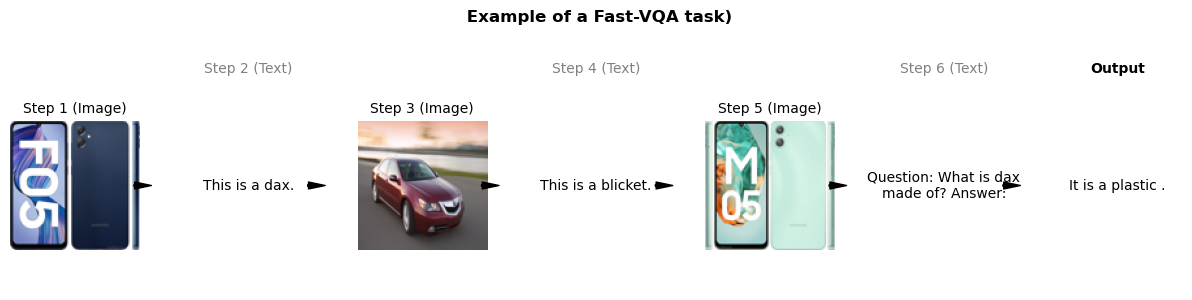

In [352]:
print("Fast-VQA task...")
img_teach_1 = load_img("car_3")   # "This is a blicket"
img_teach_2 = load_img("phone_2")   # "This is a dax"
img_query = load_img("phone_5")     # Should be "dax"
if img_teach_1 and img_teach_2 and img_query:
    prompt = [
        # Support Shots (Note the leading space for GPT-2 tokenization)
        img_teach_2, " This is a dax.\n", 
        img_teach_1, " This is a blicket.\n", 
        img_query, "Question: What is dax made of?\nAnswer:"
    ]
    output = generate_from_interleaved(model, tokenizer, prompt, max_new_tokens=10)
    print(f"Raw Output: {output}")
    show_results(prompt, prediction=output.strip(), title=" Example of a Fast-VQA task)",cols=7)
else:
    print("⚠️ Missing images for Concept Binding test.")

######
Test Case 4: Fast Concept Binding (Real-Name)
####
This test checks if the model can learn to name a category from a single example (One-Shot). The prompt provides one support image labeled with its real name (e.g., "phone") and asks the model to label a second image of the same category.

Running Real-Name Concept Binding...


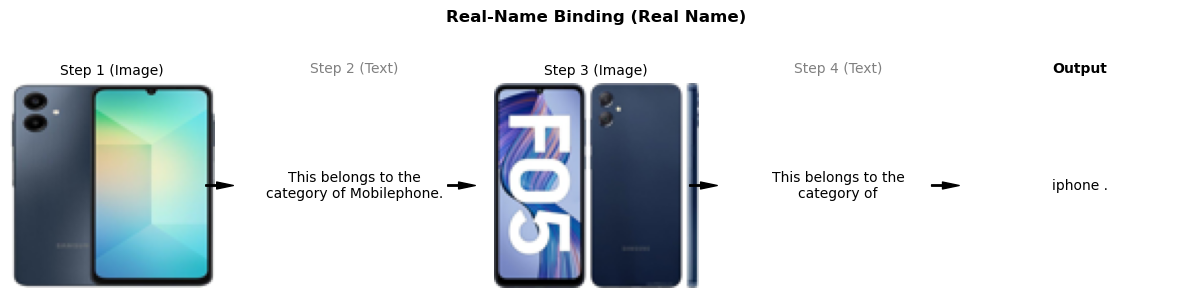

In [362]:
print("Running Real-Name Concept Binding...")

# Define images (Example: Using 'phone' as the category)
# Ideally, img_support and img_target should be DIFFERENT images of the same object.
category_name_1 = "Mobilephone"
category_name_2 = 'Animal'
img_support_1 = load_img("phone_1")
img_support_2 = load_img("lion_1") 
img_support_3 = load_img("phone_2")
img_target = load_img("phone_3") 
if img_support_1 and img_target:
    prompt = [
        # Support Shot
        img_support_1, f" This belongs to the category of {category_name_1}.\n",
        # img_support_2, f" This belongs to the category of {category_name_2}.\n",
        # img_support_3, f" This belongs to the category of {category_name_1}.\n",
        # img_support_4, f" This is an {category_name_1}.\n",
        
        # Target Query
        img_target, " This belongs to the category of "
    ]
    
    output = generate_from_interleaved(model, tokenizer, prompt, max_new_tokens=5)
    show_results(prompt, prediction=output.strip(), title=f"Real-Name Binding (Real Name)",cols=5)
else:
    print("⚠️ Missing images for Real-Name Binding test.")